# This notebook shows how to compute the full 3D strong/weak Z2 classification of a time-reversal-invariant 3D insulator, via the Z2 invariant of each of the Brillouin zone's six time-reversal-invariant planes
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The six time-reversal-invariant planes
$$ \nu_0 = z(k_i{=}0) \oplus z(k_i{=}\pi) \ \text{(any axis } i\text{)}, \qquad \nu_i = z(k_i{=}\pi) $$
where $z(k_i{=}0,\pi)$ is notebooks/12's own 2D $Z_2$ invariant, computed on the plane where reciprocal direction $i$ is fixed at a time-reversal-invariant momentum (0 or $\pi$) and the other two directions form the Wilson loop/pumping pair. $\nu_0$ (the physically decisive strong index) is basis-independent and must agree across all three choices of axis $i$ -- an algebraic identity, not a numerical coincidence.

### A dimerized diamond lattice, built with cesium
Fu \& Kane's own minimal lattice model (Phys. Rev. B 76, 045302 (2007)) for introducing $(\nu_0;\nu_1\nu_2\nu_3)$: the diamond structure (same as Si), with the second basis atom displaced along the cubic body diagonal [111] -- shortening one of the four tetrahedral bonds per atom. This is a *trigonal* distortion (space group $R\bar3m$, symmorphic), unlike a [001] tetragonal strain of the same lattice (space group $I4_1/amd$, nonsymmorphic -- see docs/design.md #21 for a dead end this distinction caused). Cesium (a single 6s valence electron) is used because its low-energy physics is close to FKM's single-orbital picture -- not a real crystal phase of cesium; `soc_scale` enhances its otherwise-too-weak single-band spin-orbit coupling to a numerically convenient scale, the same reasoning as notebook 12's enhanced-SOC graphene.

In [2]:
A = 16.0  # Bohr -- chosen only to keep Cs muffin-tin spheres non-overlapping
DELTA = 0.03  # dimerization: shortens the [111] bond (FKM's delta_t1 > 0, "dimerized")
DIAMOND_AVEC = [(0.0, A / 2, A / 2), (A / 2, 0.0, A / 2), (A / 2, A / 2, 0.0)]
CS_SPECIES = {"Cs": [(0.0, 0.0, 0.0), (0.25 - DELTA, 0.25 - DELTA, 0.25 - DELTA)]}

cs = Structure(DIAMOND_AVEC, CS_SPECIES).get_calculation(
    "_scratch/cs_dimerized_z2_3d", xc="PW", ngridk=(4, 4, 4), rgkmax=7.0,
    spinorb=True, soc_scale={"Cs": 3000.0},
)
cs.get_energy()

first_block = (cs.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)  # occupied count from EIGVAL.OUT, not an assumed electron count

### Note: this structure's $\nu_0$ has since been retracted
The value below ($\nu_0=1$) is **not** converged. The exact, mesh-free Fu-Kane parity indicator (`get_fu_kane_invariant()`, see `notebooks/15_parity_invariants.ipynb`) gives $(0;000)$ for this structure across six independently-gapped band windows, and refining the WCC mesh on a disputed plane gives $z=1,0,1,0$ for $(n_{kx},n_t)=(12,7),(18,9),(24,13),(32,17)$ -- an oscillation rather than a converged value. This hypothetical Cs diamond lattice does not realize the phase of Fu \& Kane's single-orbital tight-binding model, and the apparent agreement was coincidental (`docs/design.md` §23).

What this notebook still demonstrates correctly is the **method**: how the six plane invariants are computed and combined, and the algebraic consistency of $\nu_0$ across the three axis splits. Read the numbers below as mechanics, not as a physical claim about this structure.

In [3]:
result = cs.get_z2_invariant_3d(1, ist1, nkx=12, nt=7)
result["nu0"], result["nu0_by_axis"], result["nu"]  # strong index, per-axis check, weak indices

(1, (1, 1, 1), (0, 0, 0))

### Wannier-center trajectories on two of the six planes
The $k_1=0$ plane's WCCs wind across the largest-gap reference an odd number of times (the graphical signature of $z=1$) -- the $k_1=\pi$ plane does not.

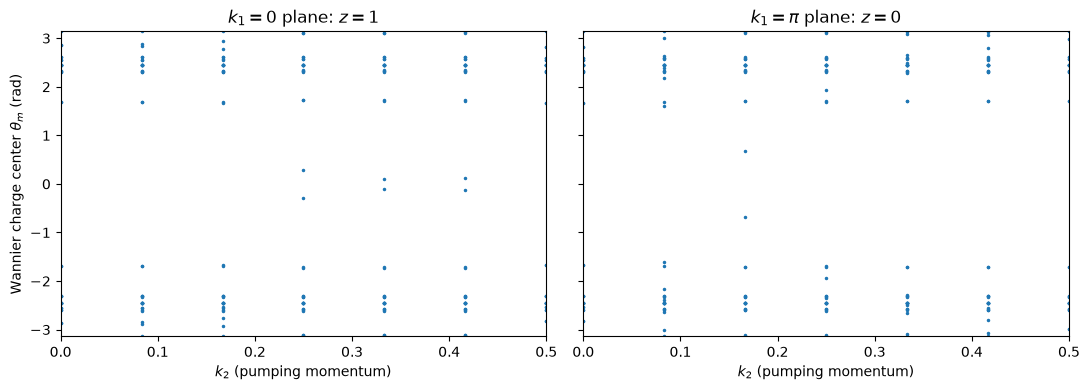

In [4]:
PLANE_LABEL = {0.0: "0", 0.5: r"\pi"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, offset in zip(axes, (0.0, 0.5)):
    plane = result["planes"][(1, offset)]
    for band in range(plane["wannier_centers"].shape[1]):
        ax.plot(plane["pump"], plane["wannier_centers"][:, band], ".", ms=3, color="C0")
    ax.set_xlabel(r"$k_2$ (pumping momentum)")
    ax.set_xlim(0, 0.5)
    ax.set_title(f"$k_1={PLANE_LABEL[offset]}$ plane: $z={plane['z2']}$")
axes[0].set_ylabel(r"Wannier charge center $\theta_m$ (rad)")
axes[0].set_ylim(-np.pi, np.pi)
plt.tight_layout()
plt.show()